In [ ]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load dataset
df = pd.read_csv("DA task.csv")

# Preview
df.head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ORGANIZATION_ID  170526 non-null  object
 1   ACTIVITY_NAME    170526 non-null  object
 2   TIMESTAMP        170526 non-null  object
 3   CONVERTED        170526 non-null  bool  
 4   CONVERTED_AT     34235 non-null   object
 5   TRIAL_START      170526 non-null  object
 6   TRIAL_END        170526 non-null  object
dtypes: bool(1), object(6)
memory usage: 8.0+ MB


## Data Cleaning

In [ ]:
# Convert column names into lowercase
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
# Drop row with many missing values
df = df[~df['converted'].isna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   organization_id  170526 non-null  object
 1   activity_name    170526 non-null  object
 2   timestamp        170526 non-null  object
 3   converted        170526 non-null  bool  
 4   converted_at     34235 non-null   object
 5   trial_start      170526 non-null  object
 6   trial_end        170526 non-null  object
dtypes: bool(1), object(6)
memory usage: 8.0+ MB


In [ ]:
# Convert datetime columns
date_cols = ["timestamp", "converted_at", "trial_start", "trial_end"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   organization_id  170526 non-null  object        
 1   activity_name    170526 non-null  object        
 2   timestamp        170526 non-null  datetime64[ns]
 3   converted        170526 non-null  bool          
 4   converted_at     34235 non-null   datetime64[ns]
 5   trial_start      170526 non-null  datetime64[ns]
 6   trial_end        170526 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](4), object(2)
memory usage: 8.0+ MB


In [ ]:
# Ensure boolean is correct
df['converted'] = df['converted'].astype(bool)

In [ ]:
# Standardize activity names
df['activity_name'] = df['activity_name'].str.replace('.', ' ')
df['activity_type'] = df['activity_name'].str.split().str[0]
df['activity_name_clean'] = df['activity_name'].str.split().str[1:].str.join(' ')

In [ ]:
print('Summary Statistics for the DataFrame:')
display(df.describe(include='all'))

Summary Statistics for the DataFrame:


,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end,activity_type,activity_name_clean
count,170526,170526,170526,170526,34235,170526,170526,170526,170526
unique,966,28,NaN,2,NaN,NaN,NaN,13,26
top,33f0b98a557961f5ccc519bb972d450f,Scheduling Shift Created,NaN,False,NaN,NaN,NaN,Scheduling,Shift Created
freq,12136,96895,NaN,136291,NaN,NaN,NaN,111128,96895
mean,NaN,NaN,2024-03-01 03:55:17.990928128,NaN,2024-03-15 04:45:07.682839296,2024-02-17 20:55:27.597691904,2024-03-18 20:55:27.597691904,NaN,NaN
min,NaN,NaN,2024-01-01 20:52:26,NaN,2024-01-26 00:39:07,2024-01-01 15:21:50,2024-01-31 15:21:50,NaN,NaN
25%,NaN,NaN,2024-02-03 05:34:51,NaN,2024-02-24 11:39:05,2024-01-22 16:04:45,2024-02-21 16:04:45,NaN,NaN
50%,NaN,NaN,2024-03-05 13:33:58,NaN,2024-03-19 22:07:32,2024-02-22 02:00:58,2024-03-23 02:00:58,NaN,NaN
75%,NaN,NaN,2024-03-24 13:41:42.500000,NaN,2024-04-04 09:37:41,2024-03-13 14:15:09,2024-04-12 14:15:09,NaN,NaN
max,NaN,NaN,2024-04-28 15:10:31,NaN,2024-05-10 13:51:28,2024-03-30 21:01:15,2024-04-29 21:01:15,NaN,NaN


In [ ]:
print('records before removing duplicates', df.shape)
print(df.duplicated().sum())
df = df.drop_duplicates()
print('records after removing duplicates', df.shape)

records before removing duplicates (170526, 9)
67631
records after removing duplicates (102895, 9)


In [ ]:
# Filter only events within trial period
df = df[(df['timestamp'] >= df['trial_start']) &
        (df['timestamp'] <= df['trial_end'])]

print('records after filtering', df.shape)

records after filtering (102895, 9)


In [ ]:
# Create derived fields
df['days_since_trial_start'] = (df['timestamp'] - df['trial_start']).dt.days

In [ ]:
# Handle missing organization_id
df = df.dropna(subset=['organization_id'])

## EDA

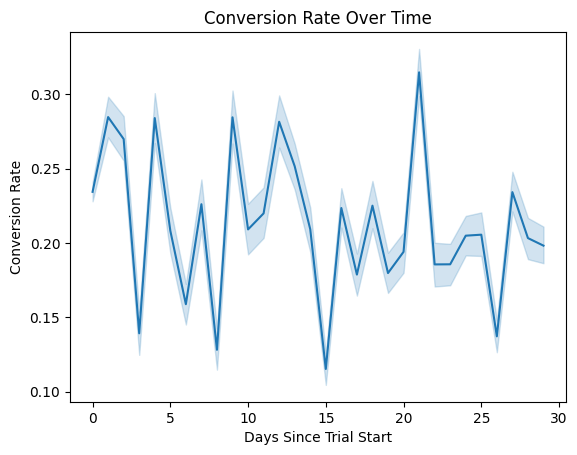

In [ ]:
sns.lineplot(data=df, x='days_since_trial_start', y='converted')
plt.title('Conversion Rate Over Time')
plt.xlabel('Days Since Trial Start')
plt.ylabel('Conversion Rate')
plt.show()

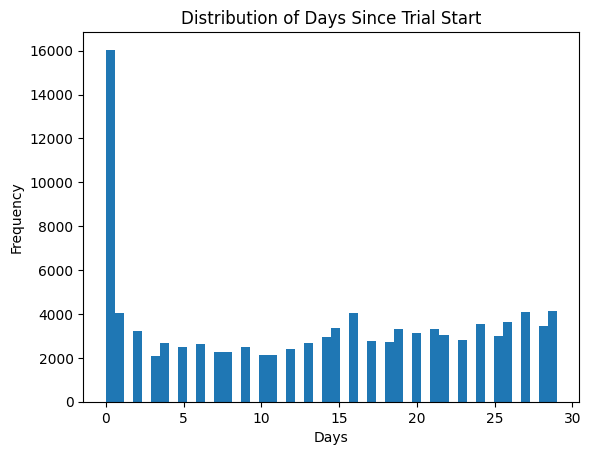

In [ ]:
df['days_since_trial_start'].plot(kind='hist', bins=50)
plt.title('Distribution of Days Since Trial Start')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

Conversion Rate

Distribution of 'converted' column:
converted
False    80672
True     22223
Name: count, dtype: int64


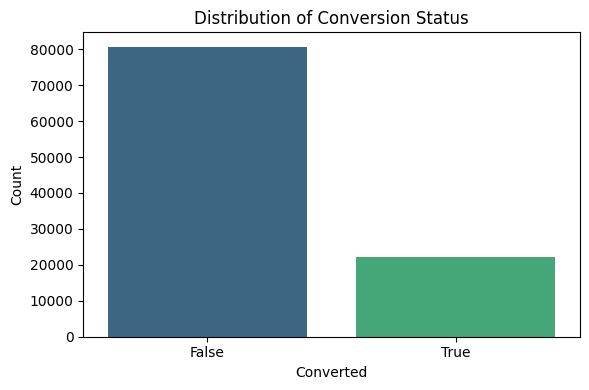

In [ ]:
print("Distribution of 'converted' column:")
print(df['converted'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='converted', hue='converted', palette='viridis', legend=False)
plt.title('Distribution of Conversion Status')
plt.xlabel('Converted')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
conversion_rate = df[['organization_id', 'converted']].drop_duplicates()['converted'].mean()
print(f"Conversion Rate: {conversion_rate:.2%}")

Conversion Rate: 21.33%


Activity Frequency

In [ ]:
activity_type_distribution = df['activity_type'].value_counts()
print("Distribution of Activity Type:")
print(activity_type_distribution)

Distribution of Activity Type:
activity_type
Mobile                 49540
Scheduling             43896
PunchClock              5047
Communication           1576
ShiftDetails            1433
Absence                  777
Break                    320
PunchClockEndNote        136
PunchClockStartNote       57
Timesheets                49
Integration               31
Revenue                   30
Shift                      3
Name: count, dtype: int64


In [ ]:
activity_name_clean_distribution = df['activity_name_clean'].value_counts()
print("Distribution of Cleaned Activity Name:")
print(activity_name_clean_distribution)

Distribution of Cleaned Activity Name:
activity_name_clean
Schedule Loaded                49540
Shift Created                  31818
Shift AssignmentChanged         7608
PunchedIn                       4833
Shift Approved                  2550
Message Created                 1576
View Opened                     1436
Availability Set                1084
Template ApplyModal Applied      468
Request Created                  388
Request Approved                 337
OpenShiftRequest Created         261
Add Completed                    193
Activate Started                 161
Activate Finished                159
PunchedOut                       123
Entry Edited                      91
Request Rejected                  52
BulkApprove Confirmed             49
ShiftSwap Created                 31
Xero PayrollExport Synced         31
Budgets Created                   30
ShiftSwap Accepted                28
ShiftHandover Created             21
ShiftHandover Accepted            21
OpenShiftRequest

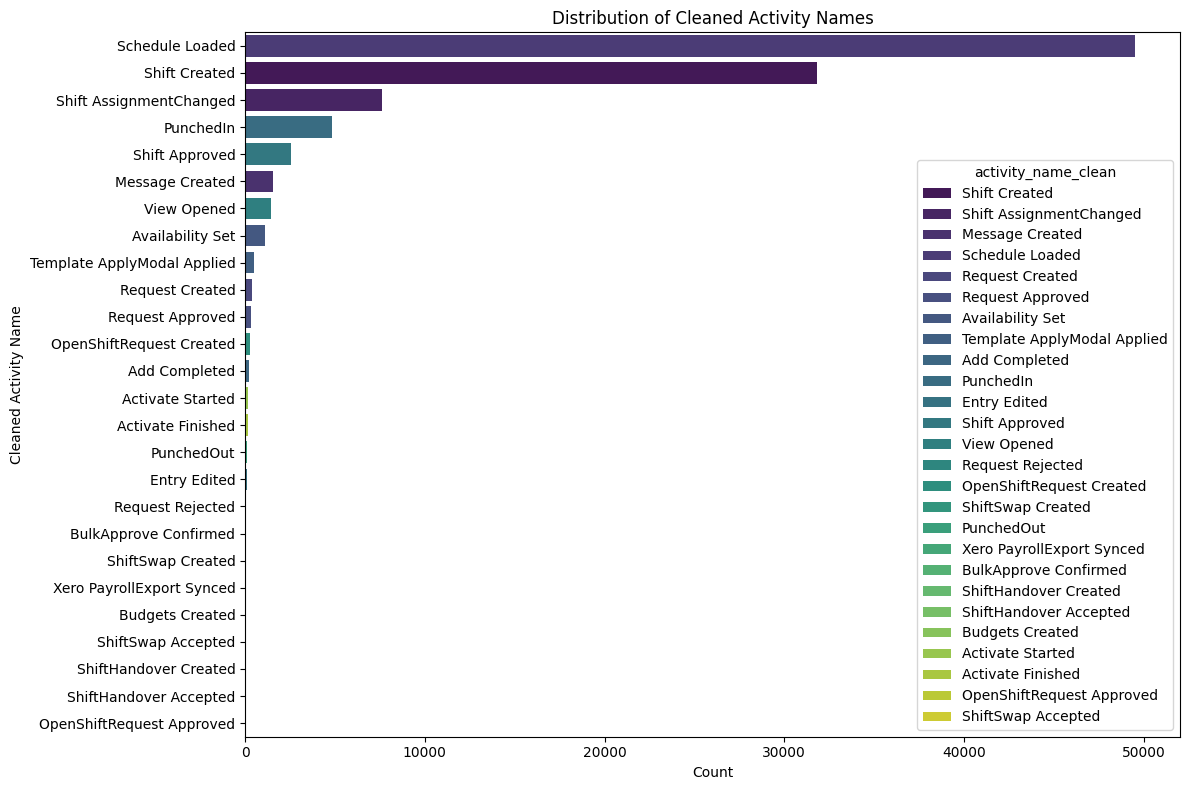

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='activity_name_clean', order=df['activity_name_clean'].value_counts().index, hue='activity_name_clean', palette='viridis', legend=True)
plt.title('Distribution of Cleaned Activity Names')
plt.xlabel('Count')
plt.ylabel('Cleaned Activity Name')
plt.tight_layout()
plt.show()

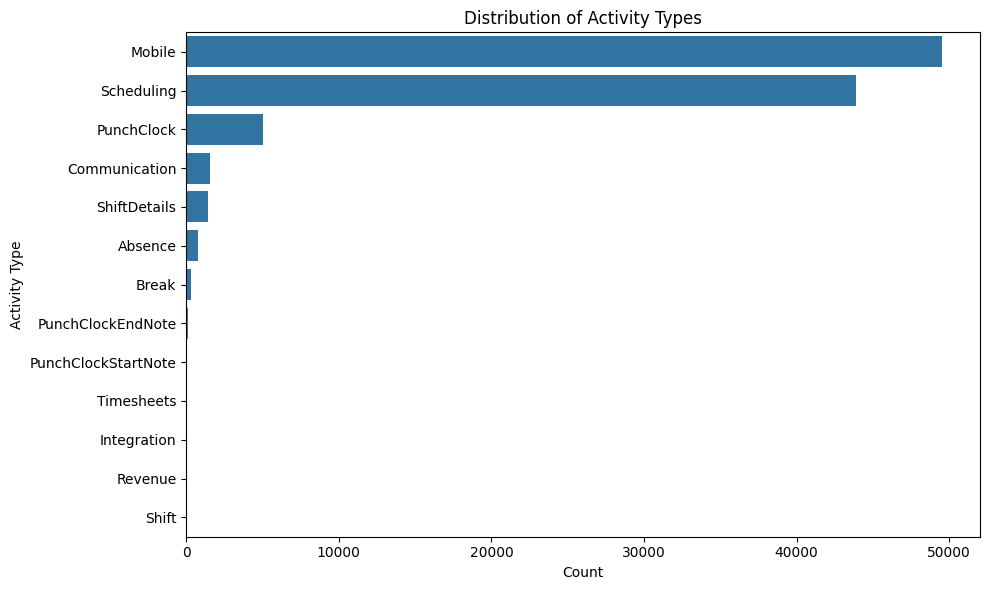

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='activity_type', order=df['activity_type'].value_counts().index)
plt.title('Distribution of Activity Types')
plt.xlabel('Count')
plt.ylabel('Activity Type')
plt.tight_layout()
plt.show()

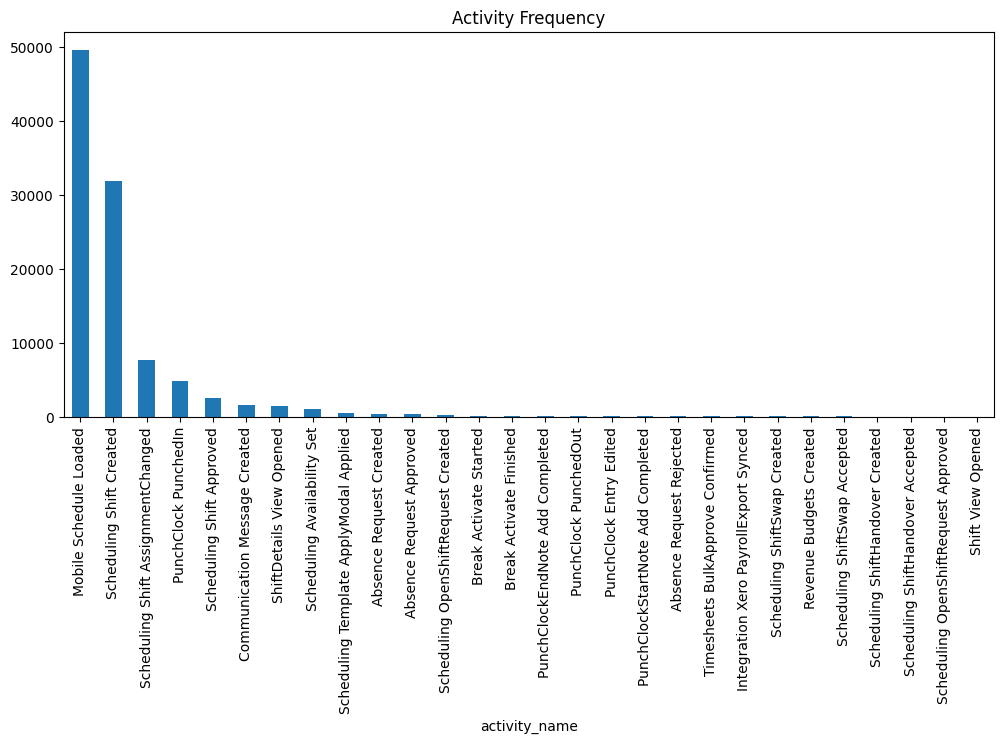

In [ ]:
activity_counts = df['activity_name'].value_counts()
activity_counts.plot(kind='bar', figsize=(12,5))
plt.title("Activity Frequency")
plt.show()

Activity → Conversion Relationship

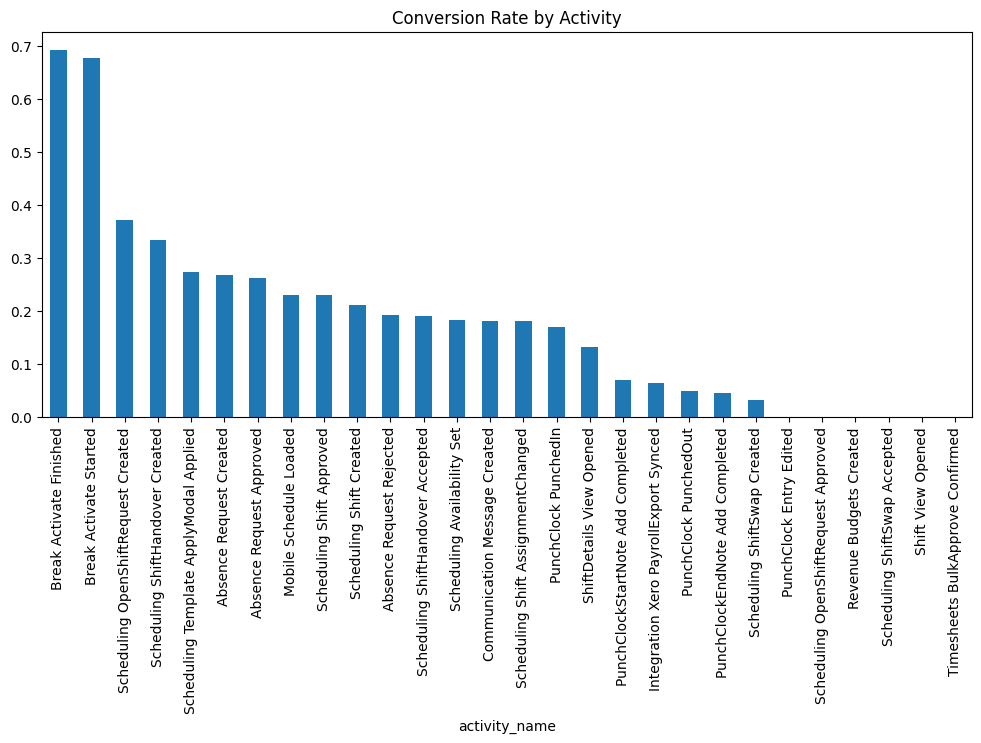

In [ ]:
activity_conversion = df.groupby('activity_name')['converted'].mean().sort_values(ascending=False)

activity_conversion.plot(kind='bar', figsize=(12,5))
plt.title("Conversion Rate by Activity")
plt.show()

In [ ]:
# Create Activity Features per Organization

# Pivot: org x activity counts
activity_pivot = df.pivot_table(
    index='organization_id',
    columns='activity_name',
    values='timestamp',
    aggfunc='count',
    fill_value=0
)

print(activity_pivot.head())
# Add conversion label
conversion = df[['organization_id', 'converted']].drop_duplicates().set_index('organization_id')

features = activity_pivot.join(conversion)

activity_name                     Absence Request Approved  \
organization_id                                              
0040dd9ab132b92d5d04bc3acf14d2e2                         3   
00456fd86311b6095ad05f7e31758f0d                         0   
007d48a2bc006e6eac0348c788d26dfd                         0   
00d6461845d0042b929379c263e9edef                         0   
00d812389a3cffdbf014ba194cbe922e                         0   

activity_name                     Absence Request Created  \
organization_id                                             
0040dd9ab132b92d5d04bc3acf14d2e2                        3   
00456fd86311b6095ad05f7e31758f0d                        0   
007d48a2bc006e6eac0348c788d26dfd                        0   
00d6461845d0042b929379c263e9edef                        0   
00d812389a3cffdbf014ba194cbe922e                        0   

activity_name                     Absence Request Rejected  \
organization_id                                              
0040dd9ab132b

In [ ]:
# Correlations

correlations = features.corr()['converted'].drop('converted').sort_values(ascending=False)
print(correlations.head(10))

Break Activate Finished                   0.052118
Break Activate Started                    0.051302
Scheduling OpenShiftRequest Created       0.039696
Scheduling Template ApplyModal Applied    0.033916
Scheduling ShiftHandover Created          0.027862
Absence Request Created                   0.012018
Mobile Schedule Loaded                    0.010998
Absence Request Approved                  0.009695
Scheduling Shift Approved                 0.008638
Scheduling Shift Created                 -0.002837
Name: converted, dtype: float64


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = features.drop(columns='converted')
y = features['converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print(importance.head(10))

Scheduling ShiftHandover Created          0.699695
Absence Request Rejected                  0.683338
Break Activate Finished                   0.275408
Absence Request Approved                  0.220421
Scheduling Template ApplyModal Applied    0.086470
Scheduling OpenShiftRequest Created       0.077782
PunchClock PunchedOut                     0.067797
ShiftDetails View Opened                  0.006634
Scheduling Shift Approved                 0.003095
Scheduling Shift Created                  0.000849
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Goal Completion per Organization

In [ ]:
trial_goals = [
    "Scheduling Shift Created",
    "Scheduling Availability Set",
    "Mobile Schedule Loaded",
    "Scheduling Shift AssignmentChanged",
    "PunchClock PunchedIn",

    "Scheduling ShiftHandover Created",
    "Scheduling ShiftHandover Accepted",
    "Absence Request Rejected",
    "Scheduling OpenShiftRequest Created",
    "Absence Request Created"
]


goal_df = df[df['activity_name'].isin(trial_goals)]

goal_completion = (
    goal_df.groupby(['organization_id', 'activity_name'])
    .size()
    .unstack(fill_value=0)
)

# Convert to binary (completed or not)
goal_completion = (goal_completion > 0).astype(int)

# Add conversion
goal_completion = goal_completion.join(conversion)

goal_completion.head()

,Absence Request Created,Absence Request Rejected,Mobile Schedule Loaded,PunchClock PunchedIn,Scheduling Availability Set,Scheduling OpenShiftRequest Created,Scheduling Shift AssignmentChanged,Scheduling Shift Created,Scheduling ShiftHandover Accepted,Scheduling ShiftHandover Created,converted
organization_id,,,,,,,,,,,
0040dd9ab132b92d5d04bc3acf14d2e2,1,1,1,1,1,0,1,1,0,0,False
00456fd86311b6095ad05f7e31758f0d,0,0,1,0,0,0,1,1,0,0,False
007d48a2bc006e6eac0348c788d26dfd,0,0,1,1,0,0,0,0,0,0,False
00d6461845d0042b929379c263e9edef,0,0,0,1,0,0,0,1,0,0,False
00d812389a3cffdbf014ba194cbe922e,0,0,1,1,0,1,1,1,0,0,False


Activation Rate

In [ ]:
# goal_completion['Absence Request Created'] = ((goal_completion[trial_goals].sum(axis=1) == len(trial_goals))
# ).astype(int)

# activation_rate = goal_completion['Absence Request Created'].mean()
# print(f"Activation Rate: {activation_rate:.2%}")

goal_completion['num_goals_completed'] = goal_completion[trial_goals].sum(axis=1)

goal_distribution = goal_completion['num_goals_completed'].value_counts().sort_index()
print(goal_distribution)

num_goals_completed
1    432
2    256
3    118
4     75
5     36
6     23
7     12
8      3
9      1
Name: count, dtype: int64


Time to Conversion

In [ ]:
time_to_convert = df[df['converted'] == True].copy()
time_to_convert['time_to_convert'] = (
    time_to_convert['converted_at'] - time_to_convert['trial_start']
).dt.days

time_to_convert.groupby('organization_id')['time_to_convert'].min().describe()

,time_to_convert
count,206.000000
mean,30.271845
std,8.207307
min,14.000000
25%,25.000000
50%,30.000000
75%,36.000000
max,64.000000


Retention (Activity Over Time)

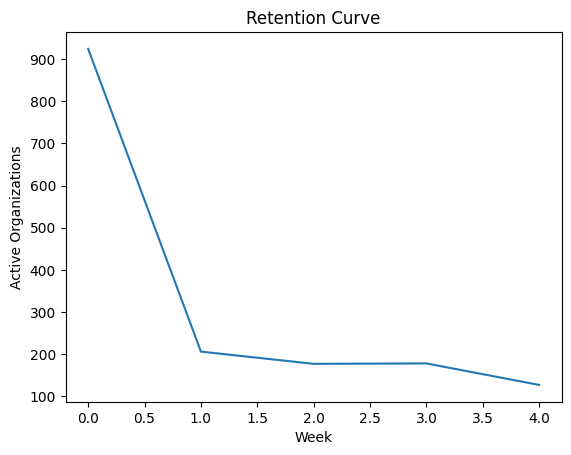

In [ ]:
df['week'] = df['days_since_trial_start'] // 7

retention = df.groupby(['week'])['organization_id'].nunique()

retention.plot()
plt.title("Retention Curve")
plt.xlabel("Week")
plt.ylabel("Active Organizations")
plt.show()


Funnel Analysis

In [ ]:
org_df = df[['organization_id', 'converted']].drop_duplicates()
# Create goal completion flags per org
goal_df = df[df['activity_name'].isin(trial_goals)]

goal_completion = (
    goal_df.groupby(['organization_id', 'activity_name'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to binary flags
goal_completion = (goal_completion > 0).astype(int)

# Ensure all goals exist as columns
for goal in trial_goals:
    if goal not in goal_completion.columns:
        goal_completion[goal] = 0

# Merge conversion
goal_completion = goal_completion.merge(org_df, on='organization_id', how='left')

goal_completion.head()

# Total organizations
total_orgs = org_df['organization_id'].nunique()

# Stage 1: Trial Started
stage_1 = total_orgs

# Stage 2: Did any key activity
stage_2 = goal_completion[
    (goal_completion[trial_goals].sum(axis=1) >= 1)
]['organization_id'].nunique()

# Stage 3: Partial completion (at least 3 goals)
stage_3 = goal_completion[
    (goal_completion[trial_goals].sum(axis=1) >= 3)
]['organization_id'].nunique()

# Stage 4: Fully activated (all goals)
goal_completion['activated'] = (
    goal_completion[trial_goals].sum(axis=1) == len(trial_goals)
).astype(int)

stage_4 = goal_completion['activated'].sum()

# Stage 5: Converted
stage_5 = goal_completion[goal_completion['converted'] == True]['organization_id'].nunique()

# Funnel dictionary
funnel = {
    "Trial Started": stage_1,
    "Any Key Activity": stage_2,
    "Partial (≥3 Goals)": stage_3,
    "Activated (All Goals)": stage_4,
    "Converted": stage_5
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=["Stage", "Organizations"])
funnel_df

,Stage,Organizations
0,Trial Started,966
1,Any Key Activity,956
2,Partial (≥3 Goals),268
3,Activated (All Goals),0
4,Converted,206


Drop-Off Analysis (This is 🔥 for interviews)


In [ ]:
funnel_df['Drop-off %'] = funnel_df['Organizations'].pct_change() * -100
funnel_df['Conversion %'] = funnel_df['Organizations'] / stage_1 * 100

funnel_df

,Stage,Organizations,Drop-off %,Conversion %
0,Trial Started,966,NaN,100.000000
1,Any Key Activity,956,1.035197,98.964803
2,Partial (≥3 Goals),268,71.966527,27.743271
3,Activated (All Goals),0,100.000000,0.000000
4,Converted,206,-inf,21.325052


In [ ]:
# Create segments
goal_completion['num_goals_completed'] = goal_completion[trial_goals].sum(axis=1)

conversion_by_stage = (
    goal_completion.groupby('num_goals_completed')['converted']
    .mean()
    .reset_index()
)

conversion_by_stage.columns = ['Goals Completed', 'Conversion Rate']

conversion_by_stage

,Goals Completed,Conversion Rate
0,1,0.203704
1,2,0.234375
2,3,0.228814
3,4,0.160000
4,5,0.194444
5,6,0.304348
6,7,0.416667
7,8,0.000000
8,9,0.000000


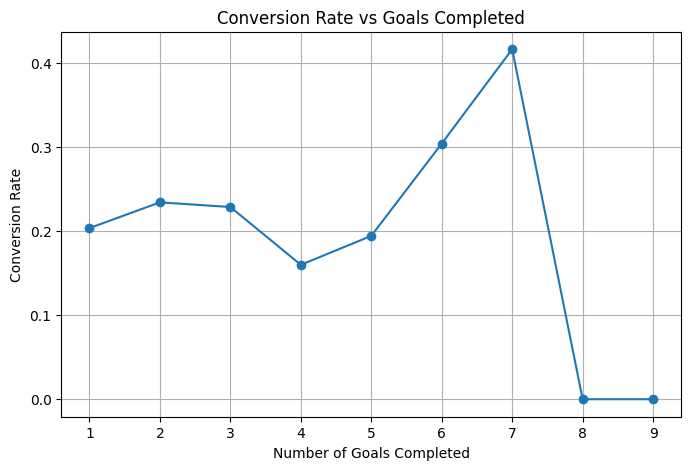

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(conversion_by_stage['Goals Completed'],
         conversion_by_stage['Conversion Rate'],
         marker='o')

plt.title("Conversion Rate vs Goals Completed")
plt.xlabel("Number of Goals Completed")
plt.ylabel("Conversion Rate")
plt.grid()
plt.show()

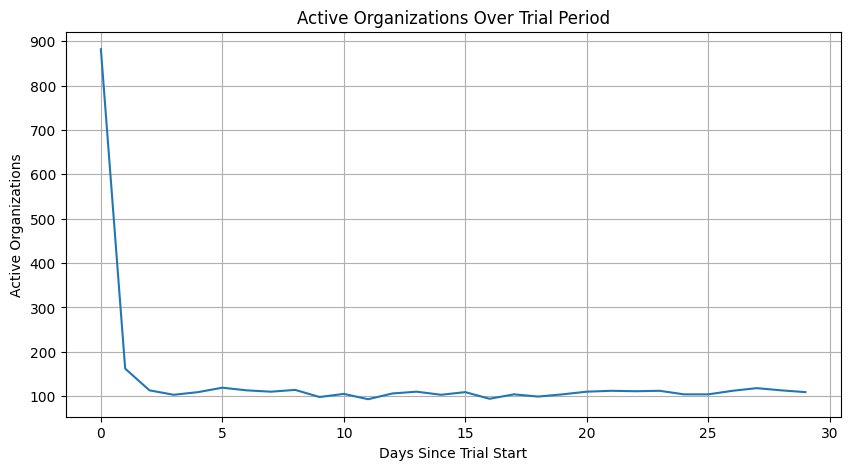

In [ ]:
df['days_since_trial_start'] = (
    df['timestamp'] - df['trial_start']
).dt.days

# Active users over time
time_funnel = (
    df.groupby('days_since_trial_start')['organization_id']
    .nunique()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(time_funnel['days_since_trial_start'],
         time_funnel['organization_id'])

plt.title("Active Organizations Over Trial Period")
plt.xlabel("Days Since Trial Start")
plt.ylabel("Active Organizations")
plt.grid()
plt.show()

In [ ]:
goal_completion['num_goals_completed'] = goal_completion[trial_goals].sum(axis=1)

goal_distribution = goal_completion['num_goals_completed'].value_counts().sort_index()
print(goal_distribution)

num_goals_completed
1    432
2    256
3    118
4     75
5     36
6     23
7     12
8      3
9      1
Name: count, dtype: int64


In [ ]:
conversion_by_goals = (
    goal_completion.groupby('num_goals_completed')['converted']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

conversion_by_goals.columns = [
    'Goals Completed',
    'Total Orgs',
    'Converted Orgs',
    'Conversion Rate'
]

print(conversion_by_goals)

   Goals Completed  Total Orgs  Converted Orgs  Conversion Rate
0                1         432              88         0.203704
1                2         256              60         0.234375
2                3         118              27         0.228814
3                4          75              12         0.160000
4                5          36               7         0.194444
5                6          23               7         0.304348
6                7          12               5         0.416667
7                8           3               0         0.000000
8                9           1               0         0.000000
